In [50]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, brier_score_loss, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import shap
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier

In [51]:
df = pd.read_csv('../Data/HRDataset_v14.csv')

df['Position'] = df['Position'].str.strip()
df = df.dropna(subset=['ManagerID'])

df['DateofHire'] = pd.to_datetime(df['DateofHire'])
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'])

# Tenure
today = datetime.now()
df['Tenure_Months'] = (today - df['DateofHire']).dt.days / 30

# Salary vs. Position Average
pos_avg_salary = df.groupby('Position')['Salary'].transform('mean')
df['Comp_Ratio'] = df['Salary'] / pos_avg_salary

# Engagement-Performance Gap
df['Norm_Perf'] = df['PerfScoreID'] / 4
df['Norm_Engage'] = df['EngagementSurvey'] / 5
df['Engage_Perf_Gap'] = df['Norm_Perf'] - df['Norm_Engage']

# Satisfaction vs Absences
df['Absence_Satisfaction_Ratio'] = df['Absences'] / (df['EmpSatisfaction'] + 1) # +1 avoids divion by 0 errors
df[['Employee_Name', 'Comp_Ratio', 'Engage_Perf_Gap']].head()

,Employee_Name,Comp_Ratio,Engage_Perf_Gap
0,"Adinolfi, Wilson K",1.124099,0.080
1,"Ait Sidi, Karthikeyan",1.021549,-0.242
2,"Akinkuolie, Sarah",1.000677,0.146
3,"Alagbe,Trina",1.168789,-0.218
4,"Anderson, Carol",0.914030,-0.250


In [52]:
categorical_features = ['Department', 'RecruitmentSource', 'Sex']
numerical_features = [
    'Tenure_Months', 'Comp_Ratio', 
    'Engage_Perf_Gap', 'Absence_Satisfaction_Ratio',
    'SpecialProjectsCount', 'Absences'
]

X = pd.get_dummies(df[categorical_features + numerical_features], drop_first = True)
y = df['Termd']

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=0))
])

brier_scorer = make_scorer(brier_score_loss, response_method='predict_proba', greater_is_better=False)
scoring = {
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'brier': brier_scorer
}

cv_results = cross_validate(pipeline, X, y, cv=rkf, scoring=scoring, n_jobs=-1)

print(f"--- Logistic Regression Validation Results (Mean ± Std) ---")
print(f"ROC-AUC: {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")
print(f"F1-Score: {cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}")
print(f"Brier Score: {cv_results['test_brier'].mean():.3f} ± {cv_results['test_brier'].std():.3f}")

--- Logistic Regression Validation Results (Mean ± Std) ---
ROC-AUC: 0.738 ± 0.055
F1-Score: 0.632 ± 0.064
Brier Score: -0.210 ± 0.026


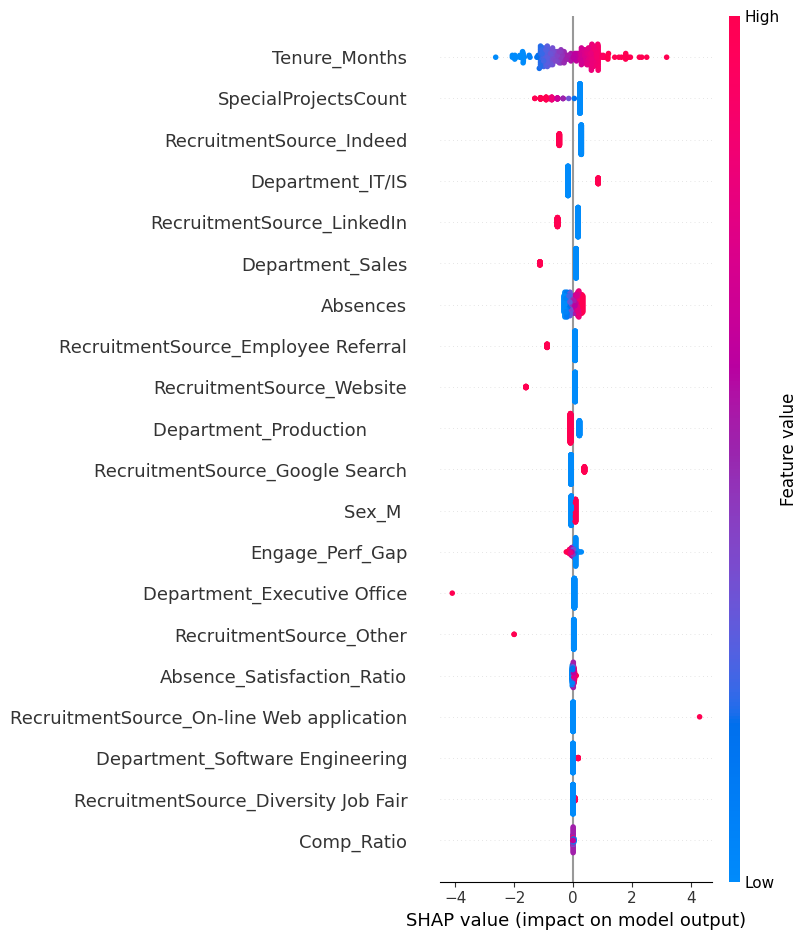

In [53]:
pipeline.fit(X, y)
explainer = shap.Explainer(pipeline.named_steps['model'], pipeline.named_steps['scaler'].transform(X), feature_names=X.columns)
shap_values = explainer(pipeline.named_steps['scaler'].transform(X))
shap.summary_plot(shap_values, X, feature_names=X.columns)

In [54]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

rf_cv_results = cross_validate(rf_pipeline, X, y, cv=rkf, scoring=scoring, n_jobs=-1)

print(f"--- Random Forest Validation Results (Mean ± Std) ---")
print(f"ROC-AUC: {rf_cv_results['test_roc_auc'].mean():.3f} ± {rf_cv_results['test_roc_auc'].std():.3f}")
print(f"F1-Score: {rf_cv_results['test_f1'].mean():.3f} ± {rf_cv_results['test_f1'].std():.3f}")
print(f"Brier Score: {rf_cv_results['test_brier'].mean():.3f} ± {rf_cv_results['test_brier'].std():.3f}")

--- Random Forest Validation Results (Mean ± Std) ---
ROC-AUC: 0.780 ± 0.049
F1-Score: 0.625 ± 0.071
Brier Score: -0.173 ± 0.019


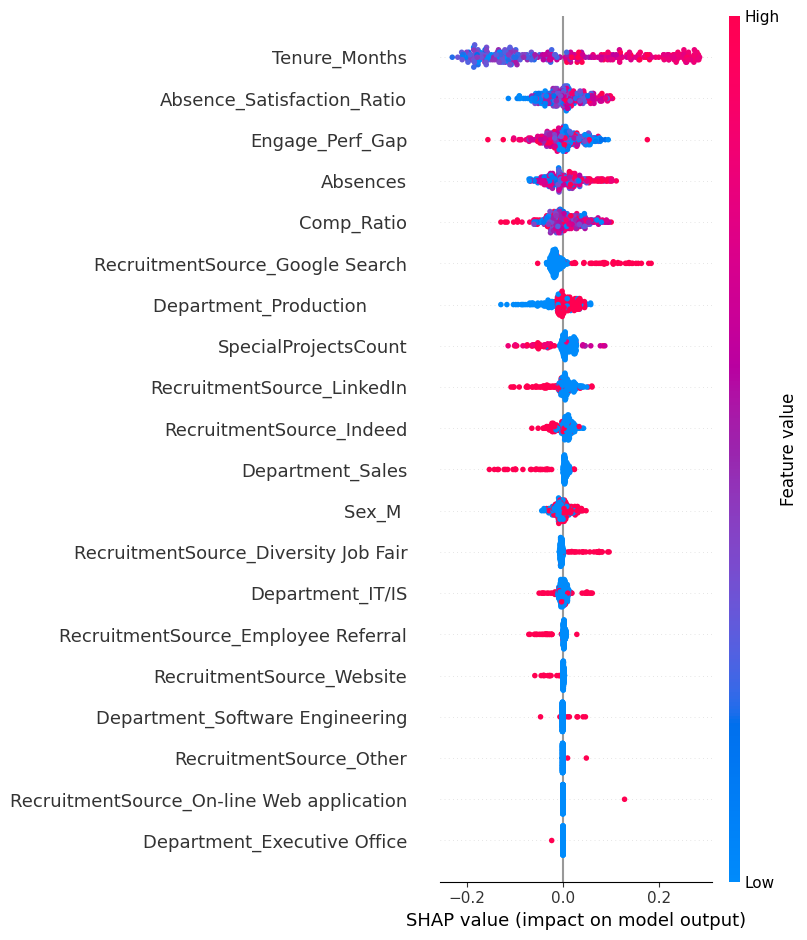

In [55]:
X_numeric = X.astype(float)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=0)
rf_model.fit(X_numeric, y)
explainer = shap.Explainer(rf_model, X_numeric)
shap_values = explainer(X_numeric)
shap.summary_plot(shap_values.values[:, :, 1], X_numeric)